In [9]:

from filterpy.kalman import EnsembleKalmanFilter as EnKF

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

from numpy.random import multivariate_normal
from filterpy.stats import (covariance_ellipse, 
                            plot_covariance_ellipse, plot_covariance)
import matplotlib
import scipy as sp
from scipy.integrate import solve_ivp 
from numba import jit, cfunc
from numbalsoda import lsoda_sig, lsoda

import time

matplotlib.rcParams["xtick.labelsize"]=12
matplotlib.rcParams["ytick.labelsize"]=12
matplotlib.rcParams["axes.labelsize"]=14
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'


In [10]:
def full_state_plots(xaxis, observation_times, observations, estimates, Pmat, save_fig=False, save_path=""):

    fig, ax = plt.subplots(3,1, figsize=(8, 7), sharex=True, layout="constrained")

    for j in range(3):
        ax[j].plot(xaxis, estimates[:,j] + 3*np.sqrt(Pmat[:,j, j]) , color="g", 
                    linestyle="--", alpha=0.5, linewidth=0.8) 
        ax[j].plot(xaxis, estimates[:,j] - 3*np.sqrt(Pmat[:,j, j]) , color="g", 
                    linestyle="--", alpha=0.5, label =r"$\pm 3 \sigma_d$", linewidth=0.9) 
        ax[j].fill_between(xaxis, estimates[:,j] - 3*np.sqrt(Pmat[:,j, j]),
                            estimates[:, j] + 3*np.sqrt(Pmat[:,j, j]), color="y", alpha=0.2) 

    ax[0].plot(observation_times[1:], observations[1:,0], "bo", markersize=1, label="observations")
    ax[0].plot(xaxis, estimates[:,0], "--r", label="EnKF", linewidth=0.9) 
    ax[0].set_ylabel(r"$a$")
    ax[0].set_ylim((-15,15)) 
    ax[0].legend(loc="upper right", fontsize=12) 
    ax[1].plot(observation_times[1:], observations[1:,1], "bo", markersize=1, label="observations")

    ax[1].plot(xaxis, estimates[:,1], "--r", linewidth=0.9) 
    ax[1].set_ylabel(r"$\dot{a}$", fontsize=12)
    ax[1].set_ylim((-10,10)) 

    ax[2].plot(observation_times[1:], observations[1:,2], "bo", markersize=1, label="observations")

    ax[2].plot(xaxis, estimates[:,2], "--r", linewidth=0.9) 
    ax[2].set_ylabel(r"$b$")
    ax[2].set_xlabel(r"$t$")
    ax[2].set_ylim((-0.5,0.5)) 

    if save_fig:
        plt.savefig("ENKF_rewritten_figures/ANAET/full_state_measurement/state_predictions_full_observations.png", 
                    bbox_inches="tight", dpi=400) 

    parameter_labels = [r"$\gamma_r$", r"$\mu_1$", r"$\delta_1$", r"$\mu_2$",
                    r"$\mu_6$", r"$\nu_1$", r"$\nu_2$", r"$\delta_0$"]

    fig, ax = plt.subplots(4,2, figsize=(8,7), layout="constrained", sharex=True)
    pp=0 
    for i in range(4):
        for j in range(2):
            lower_pp = estimates[:,pp+3] - np.sqrt(Pmat[:,pp+3, pp+3])
            upper_pp = estimates[:,pp+3] + np.sqrt(Pmat[:,pp+3, pp+3])
            min_range=np.nanmin(lower_pp) 
            max_range=np.nanmax(upper_pp) 

            if x0[pp+3]<min_range:
                min_range = np.copy(x0[pp+3])
            if x0[pp+3]>max_range:
                max_range = np.copy(x0[pp+3]) 
            
            min_range = min_range - 0.05*np.abs(min_range)
            max_range = max_range + 0.05*np.abs(max_range)
                
            ax[i,j].set_ylim((min_range, max_range)) 
            ax[i,j].plot(xaxis, estimates[:,pp+3], "r", label=parameter_labels[pp], linewidth=0.9)
            ax[i,j].plot(xaxis, np.ones(xaxis.shape[0])*x0[pp+3], "--k", label="True",
                        alpha=0.7, linewidth=0.9) 
            ax[i,j].plot(xaxis, upper_pp , color="g", 
                        linestyle="--", alpha=0.5, linewidth=0.9) 
            ax[i,j].plot(xaxis, lower_pp , color="g", 
                        linestyle="--", alpha=0.5, label=r"$\pm \sigma_d$", linewidth=0.9) 
            ax[i,j].fill_between(xaxis, lower_pp,
                                upper_pp, color="y", alpha=0.2) 

            pp+=1
            ax[i,j].legend(loc="upper right", fontsize=12) 
            
    ax[3,0].set_xlabel(r"$t$")
    ax[3,1].set_xlabel(r"$t$") 

    if save_fig:
        plt.savefig("ENKF_rewritten_figures/ANAET/full_state_measurement/parameter_predictions_full_observations.png", 
                    bbox_inches="tight", dpi=400) 

<div class="alert alert-block alert-warning">

## The ANAET system 
A number of models have been written to describe oscillatory behaviour in tokamaks. In this script we focus on the ANAET model which is a model with 3 degrees of freedom
\begin{align}
\dot{a} &= v,\\
\dot{v} &= - \gamma_0 a + (\mu_2 b -\mu_1)a^3 - \mu_6 a^6v,\\
\dot{b} &= \nu_1 - \nu_2 b^2 + (\delta_1 b - \delta_0)a^2.
\end{align}
The above system has 8 unknown parameters (though since this work it has been shown that this can be reduced substantially). For the majority of examples we will set $\mu_1=0$ as this term produces similar behaviour to the term in $\mu_2$. 

When considering applications to experimental time series, we generally assume that we will only have observations of $\dot{a}$ and $b$. From this, we need EnKF to infer
1. The parameters of the model
2. The unobserved state $a$.

This is challenging for a number of reasons because
1. We do not know the appropriate choice of parameters beforehand
2. We do not know the degree of noise
3. The ANAET system is multiscale and sensitive to parameter selection. 

**If you are planning on using this model, you should refer to**:

Arter, Wayne. (2025). Spiking With and Without Blue-Sky Catastrophe. International Journal of Bifurcation and Chaos. 35. 10.1142/S0218127425501573. 

**In particular, the model can be written in terms of fewer parameters and for realistic future applications this should be considered.** 
</div>

***

## Generate the observational data
This cell contain the relevant subroutines for creating the data and also defines numba lsoda models with constant model parameters which are used with the EnKF subroutine. 

<div class="alert alert-block alert-info">
<b> Important limitation: </b> 

The ANAET model tends to be difficult to integrate, requiring tight tolerances and a stiff solver. One unfortunate consequence of using `scipy` is that, when we are evolving the ensemble members it is difficult to avoid constantly restarting `solve_ivp` which has overhead associated with restarts. This becomes extremely expensive when assimilation windows shorten, one way of improving this is to use `numbalsoda`. You can also consider trying to use the lower-level classes in `scipy.integrate.solve_ivp` and manually stepping them. 
</div>

final time 999.9000000000001
10% of signal standard deviation 0.3207527156444572
10% of signal standard deviation 0.2582827677414251
10% of signal standard deviation 0.00593635182631412
assimilation time-steps 0.55
The solvers give different solutions eventually as a result of the different tolerances
This doesn't really matter with EnKF though over assimilation time-steps


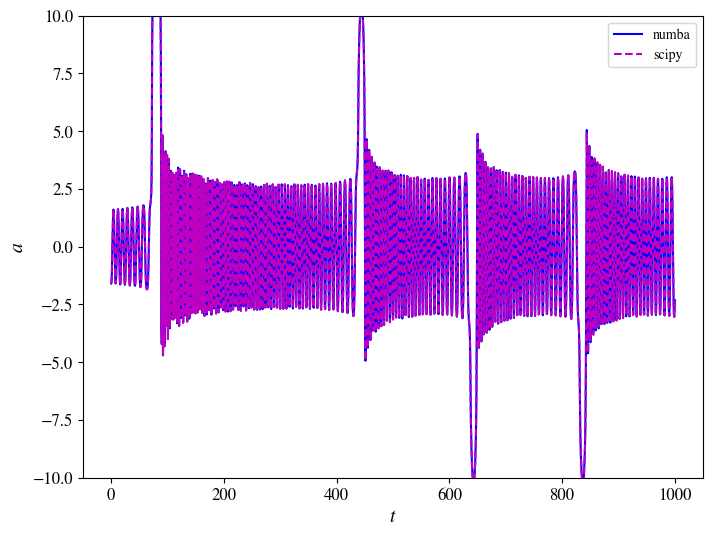

In [11]:
#pre-compiled ANAET numba function 
@cfunc(lsoda_sig) 
def anaet_numba(t,u, du, p):
    du[0] = u[1]
    du[1] = -u[3]*u[0]-(u[4]+u[6]*u[2])*(u[0]**3)-u[7]*(u[0]**6)*u[1]
    du[2] = u[8] - u[9]*(u[2]**2)-(u[10]+u[5]*u[2])*(u[0]**2)
    du[3] = 0 
    du[4] = 0
    du[5] = 0
    du[6] = 0
    du[7] = 0
    du[8] = 0
    du[9] = 0
    du[10] = 0 
    
func_address = anaet_numba.address 

#function for scipy
def ANAET(dt, x):
    return np.array([
        x[1], 
        -x[3]*x[0]-(x[4]+x[6]*x[2])*(x[0]**3)-x[7]*(x[0]**6)*x[1], 
        x[8] - x[9]*(x[2]**2)-(x[10]+x[5]*x[2])*(x[0]**2),
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0]
     )

#the parameters used in the model
gammar = 1.0 #x3
mu1 = 0.0 #x4
delta1 = 0.0 #x5
mu2 = -2.0 #x6
mu6 = 0.0001  #x7
nu1 = 0.001 #x8
nu2 = 0.005 #x9
delta0 = 0.0001 #x10
x0 = np.array([-1.6, -9.9e-02,  8.6e-02,  gammar, mu1, delta1, mu2, mu6, nu1,  nu2,  delta0])

dt_phase_model = 0.001
t_span = [0, 1000]
observation_sub = 550 #this is set to get roughly 6 samples per fastest oscillation

observation_times = np.array([dt_phase_model*observation_sub*i for i in \
                              range(int(t_span[-1]/(dt_phase_model*observation_sub))+1)]) 
print("final time", observation_times[-1]) 

# Generate synthetic data with scipy
observations_scipy =  solve_ivp(ANAET, 
                         t_span=t_span, 
                         y0 = x0, 
                         t_eval=observation_times, 
                         method="RK45", 
                         rtol=1e-6,
                         atol=1e-8, vectorized=False).y.T 


usol, success = lsoda(func_address, x0, observation_times, rtol = 1e-12, atol=1e-12)
observations = np.zeros(usol.shape)
truth = np.copy(usol) 


true_signal_stds = []
fraction_of = 0.1
for i in range(3):
    signalstd = np.std(usol[:,i])
    true_signal_stds.append(fraction_of*signalstd) 
    print("10% of signal standard deviation", fraction_of*signalstd)
    observations[:,i] = usol[:,i]+ np.random.normal(loc=0, 
                                          scale=fraction_of*signalstd, 
                                          size=usol.shape[0])

plt.figure(figsize=(8,6)) 
plt.plot(observation_times, usol[:,0], "b", label="numba")
plt.plot(observation_times, observations_scipy[:,0], "--m", label="scipy")
plt.xlabel(r"$t$")
plt.ylabel(r"$a$")
plt.legend(loc="upper right") 
plt.ylim((-10,10)) 


print("assimilation time-steps", observation_times[1]-observation_times[0]) 
print("The solvers give different solutions eventually as a result of the different tolerances")
print("This doesn't really matter with EnKF though over assimilation time-steps") 

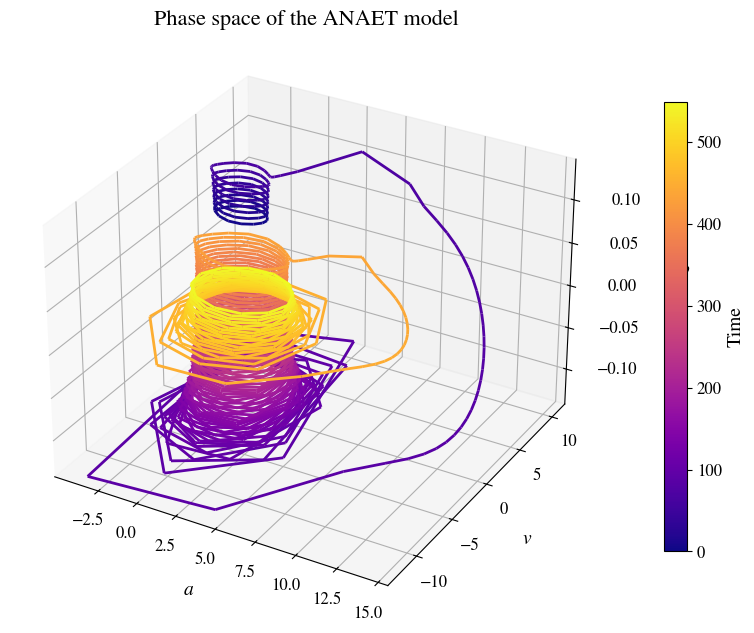

In [12]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Create line segments for the Lorenz attractor
tend = 1000

points = np.array([usol[:tend,0], usol[:tend,1], usol[:tend,2]]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)


# Create a Line3DCollection with a gradient
lc = Line3DCollection(segments, cmap='plasma', linewidth=1.
                     #norm=plt.Normalize(0, 1)
                     )
lc.set_array(observation_times[:tend])
lc.set_linewidth(2)

# Add the collection to the plot
ax.add_collection(lc)

# Set plot limits
ax.set_xlim(usol[:tend,0].min(), usol[:tend,0].max())
ax.set_ylim(usol[:tend,1].min(), usol[:tend,1].max())
ax.set_zlim(usol[:tend,2].min(), usol[:tend,2].max())
ax.tick_params(axis='z', which='major', pad=15)
# Set labels
ax.set_xlabel(r"$a$", labelpad=10)
ax.set_ylabel(r"$v$", labelpad=10)
ax.set_zlabel(r"$b$", labelpad=30)
ax.set_title(r"Phase space of the ANAET model", fontsize=16, pad=-10)
plt.tight_layout()

# Add color bar
cb = fig.colorbar(lc, ax=ax, pad=0.08, shrink=0.6, location="right")
cb.set_label(r'Time')

## Full-state measurements
Here we run the case of full-state parameters ($a, v, b$) by performing integration over assimilation intervals. So our SSM receives start and end-points which are `[0,dt_assim]` and integrates in this interval. After this all covariance matrices are calculated in one go. This is much faster than integrating in the interval `[0, dt_phase_model]` but of course this is **ONLY VALID FOR DETERMINISTIC ENKF**. 

We begin by defining some functions needed for integrating the ANAET model. EnKF expects a function to be passed which returns the evaluation of the space-state model at the next time-step. 

In [13]:
#numba integration class for enkf
def ANAET_numba_fx(x, dt, dt_interval, trange):
    return lsoda(func_address, x, 
                 trange,
                 rtol = 1e-6, atol=1e-8)[0][1:,:]

## Initialising the EnKF class
We now initialise the EnKF class. This means specifying

1. The observation operator $\boldsymbol{H}$, 
2. The initial covariance matrix $\boldsymbol{P}$,
3. The initial guess of our means $\boldsymbol{x}$,
4. The number of observables $m$,
5. The number of ensemble members $N$,
6. The time-step for the space-state model $dt$
7. The process noise (or model error) $\boldsymbol{Q}$. In our examples we use deterministic EnKF so $\boldsymbol{Q} = 0$ always here.

*** 

We being by specifying the diagonal elements of the observation operator $\boldsymbol{H}$. In this case the observations are direct, meaning the observations relate directly to the corresponing output time-series of the numerical space-state model. In this first example, we use observations of $a$, $v$ and $b$ from the ANAET system. 

In [14]:
#define the observation operator. we initially use fullstate observations
#Return an (N, z) matrix 
@jit(nopython=True) 
def hx(x):
    return x[:,:3]


We now specify the diagonal elements of the initial covariance matrix $\boldsymbol{P}$. For the ANAET system, we can explicitly write the matrix 
\begin{equation}
    \boldsymbol{P} = 
    \begin{bmatrix}
    \sigma_{aa}^2 & & & & & & & & & & 0  \\
    & \sigma_{vv}^2  & & & & & & & & &  \\
    & & \sigma_{bb}^2  & & & & & & & &  \\
    & & & \sigma_{\gamma_r\gamma_r}^2  & & & & & & &  \\
    & & & & \sigma_{\mu_1 \mu_1}^2  & & & & & &  \\
    \vdots & & & & & \sigma_{\delta_1 \delta_1}^2  & & & & & \vdots\\ 
    & & & & & & \sigma_{\mu_2 \mu_2}^2 & & & & \\
    & & & & & & & \sigma_{\mu_6 \mu_6}^2 & & &\\
    & & & & & & & & \sigma_{\nu_1 \nu_1}^2 & & \\
    & & & & & & & & & \sigma_{\nu_2 \nu_2}^2 & \\
     0 & & & & & & & & & & \sigma_{\delta_0 \delta_0}^2 
    \end{bmatrix}
\end{equation}
We also specify the process noise as $\boldsymbol{Q} = \boldsymbol{0}$ for deterministic EnKF.

In [15]:

#List the standard deviations 
scales_std = np.array([1,1,0.1, 
                              1, 
                              0.1,  
                              0.1, 
                              2, 
                              1e-4, 
                              1e-3, 
                              5e-3, 
                              1e-4]) 

#Specify the diagonals of P
initial_covariance = np.diag([true_signal_stds[0]**2,true_signal_stds[1]**2, true_signal_stds[2]**2, #set uncertainty in observables to expect noise variance
                              1**2,
                              0.1**2, 
                              0.1**2, 
                              2**2, 
                              1e-4**2, 
                              1e-3**2, 
                              5e-3**2, 
                              1e-4**2 
                             ])


#Define the process noise 
Q=np.zeros((x0.shape[0],x0.shape[0])) 

We finally instantiate the EnKF class with the different specified initial conditions. To fully instantiate the class, we also specify the initial condition for the means given by $\boldsymbol{x}$ in the class. For this, we use the true parameters value and perturb them by a small amount. The ANAET system is very sensitive to changes in parameters, so some care must be taken when initialising the different parameters. If you choose arbitrary values for the initial parameters, the routine will quickly break down. 

In [16]:
#perturb the initial condition
rng_ics = np.random.default_rng(1)
x0perturb = x0 + np.array([rng_ics.normal(loc=0, scale=scales_std[jj], size=1)[0] \
                           for jj in range(scales_std.shape[0])])

x0perturb[:3] = observations[0,:3]# as we are observing all the states we use this as an initial condition


if initial_covariance[4,4]==0:
    x0perturb[4:6] = 0 #if you are not fitting zero parameters, set these to zero 
dt_phase_model = 0.01



#instantiate the class 
enkf = EnKF(x=x0perturb, 
                inf=1., 
                P=initial_covariance, 
                dim_z=3, 
                dt=dt_phase_model, 
                hx=hx,
                N=100, 
                fx=ANAET_numba_fx,
                seed=1,
                inf_a = None, 
                qscales = None,
                constraints = None
           )


enkf.Q = Q 
enkf.R = np.diag([sd**2 for sd in true_signal_stds]) 


## Data-assimilation
We now come to the main data-assimilation routine which simply continues to predict the future until an observation becomes available. 

In this cell, we have made one modification of the original EnKF class for the sake of performance. As our observations are sparse, we integrate the models at time $t$ once over the entire interval $[t, t+t_{assim}]$, rather than in a for loop for each $dt$ until we reach $dt_{assim}$. This greatly improves the speed of assimilation, however may not be valid when using process noise. This depends if process noise is to be added on the integration time-steps $dt$, or assimilation time-steps $dt_{assim}$. 

Performing integration over the window $[t, t+t_{assim}]$ also means that observations do not need to specified on a non-uniform timegrid. Expictly we do not require that the assimilation time $dt_{assim} = n*dt$ for $n\in \mathbb{N}$, which is required in the Kalman Filter. 

In [ ]:
time_prediction = np.array([i*dt_phase_model for i in range(int(observation_times[-1]/dt_phase_model)+1)])

# creates data-arrays to store the results 
estimates = np.zeros((time_prediction.shape[0], x0.shape[0]))
estimates[0,:] =x0perturb
Pmat = np.zeros((time_prediction.shape[0], x0.shape[0], x0.shape[0]))
Pmat[0,:,:] = initial_covariance
update_counter = 0 



starttime = time.time()
tzero = 0
#perform assimilation over intervals
for ii, t in enumerate(observation_times[1:]):
    if ii%100==0:
        print("assimilating time", t) 
    dt_interval = np.round(t-tzero, decimals = 5)
    
    #perform forward evolution of the ensemble members and assimilate the observation 
    means, Ppriors = enkf.predict_anaet(dt_interval) 

    enkf.update(observations[np.isclose(t, observation_times,rtol=1e-8,
                                        atol=dt_phase_model*1e-8),:3][0]) #this check can fail at larger times
    update_counter+=1
        
    #save various diagnostics
    if t!=observation_times[-1]:
        Pmat[ii*means.shape[0]+1:(ii+1)*means.shape[0]+1,:,:] = Ppriors #we only have priors here 
        Pmat[(ii+1)*means.shape[0], :, :] = enkf.P #set to the assimilated P
        estimates[ii*means.shape[0]+1:(ii+1)*means.shape[0]+1,:] = means# Extract only state variables from the state vector
        estimates[(ii+1)*means.shape[0], :] = enkf.x
    else:
        Pmat[ii*means.shape[0]+1:,:,:] = Ppriors #we only have priors here 
        Pmat[-1, :, :] = enkf.P #set to the assimilated P
        estimates[ii*means.shape[0]+1:,:] = means# Extract only state variables from the state vector
        estimates[-1, :] = enkf.x        
    tzero = np.copy(t) 



print("total time", time.time() - starttime, "s") 
print("updated", update_counter, "times") 
estimates = np.asarray(estimates)

assimilating time 0.55
assimilating time 55.550000000000004
assimilating time 110.55000000000001
assimilating time 165.55
assimilating time 220.55
assimilating time 275.55
assimilating time 330.55
assimilating time 385.55
assimilating time 440.55
assimilating time 495.55000000000007
assimilating time 550.5500000000001
assimilating time 605.5500000000001
assimilating time 660.5500000000001
assimilating time 715.5500000000001
assimilating time 770.5500000000001
assimilating time 825.5500000000001
assimilating time 880.5500000000001
assimilating time 935.5500000000001
assimilating time 990.5500000000001
total time 12.554435968399048 s
updated 1818 times


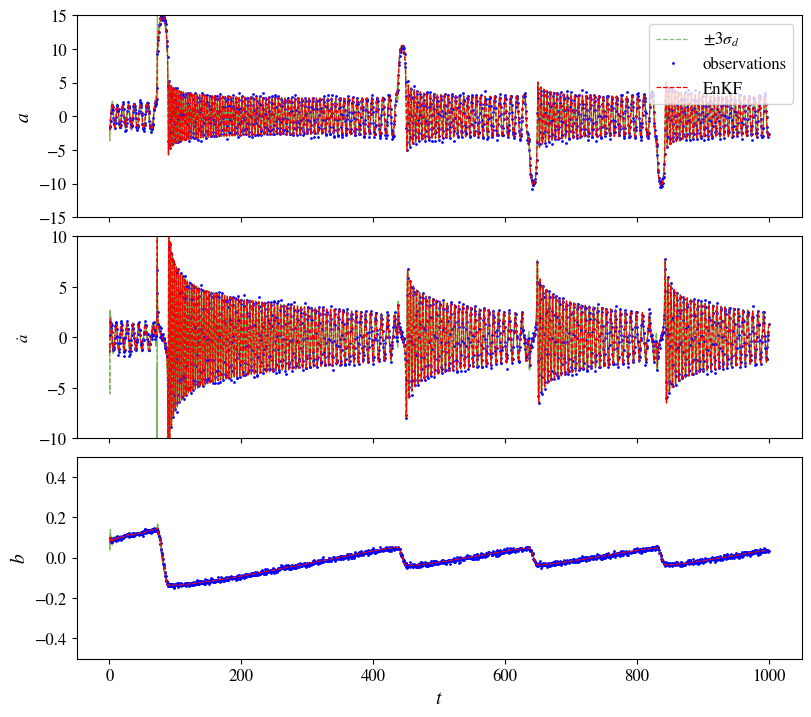

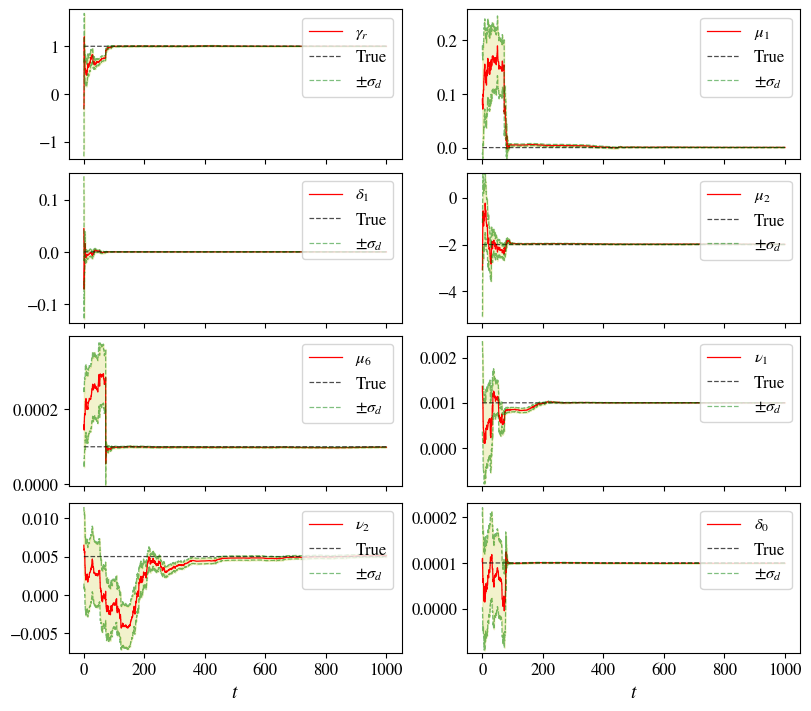

In [18]:
full_state_plots(time_prediction, observation_times, observations, estimates, Pmat, save_fig=False, 
                 save_path="ENKF_rewritten_figures/ANAET/full_state_measurement/")

## Perform data assimilation but do not save the means at every integration time-step
In this example, we perform the same computation but instead only calculate the means and priors at assimilation time-steps rather than every integration time-step. This means the code runs slightly faster but we only have priors computed at assimilation steps so the results can look less "smooth". 

In [19]:
#instantiate the class 
enkf = EnKF(x=x0perturb, 
                inf=1., 
                P=initial_covariance, 
                dim_z=3, 
                dt=dt_phase_model, 
                hx=hx,
                N=100, 
                fx=ANAET_numba_fx,
                seed=1,
                inf_a = None, 
                qscales = None
           )


enkf.Q = Q 
enkf.R = np.diag([sd**2 for sd in true_signal_stds]) 

time_prediction = np.array([i*dt_phase_model for i in range(int(observation_times[-1]/dt_phase_model)+1)])

# creates data-arrays to store the results 
estimates = np.zeros((observation_times.shape[0], x0.shape[0]))
estimates[0,:] =x0perturb
Pmat = np.zeros((observation_times.shape[0], x0.shape[0], x0.shape[0]))
Pmat[0,:,:] = initial_covariance
update_counter = 0 



starttime = time.time()
tzero = 0
#perform assimilation over intervals
for ii, t in enumerate(observation_times[1:]):
    if ii%100==0:
        print("assimilating time", t) 
    dt_interval = np.round(t-tzero, decimals = 5)
    enkf.predict_assimilation_steps(dt_interval) 

    enkf.update(observations[np.isclose(t, observation_times,rtol=1e-8,
                                        atol=dt_phase_model*1e-8),:3][0]) #this check can fail at larger times
    update_counter+=1
        

    Pmat[ii+1,:,:] = enkf.P #we only have priors here 
    estimates[ii+1,:] = enkf.x# Extract only state variables from the state vector
   
    tzero = np.copy(t) 



print("total time", time.time() - starttime, "s") 
print("updated", update_counter, "times") 
estimates = np.asarray(estimates)

assimilating time 0.55
assimilating time 55.550000000000004
assimilating time 110.55000000000001
assimilating time 165.55
assimilating time 220.55
assimilating time 275.55
assimilating time 330.55
assimilating time 385.55
assimilating time 440.55
assimilating time 495.55000000000007
assimilating time 550.5500000000001
assimilating time 605.5500000000001
assimilating time 660.5500000000001
assimilating time 715.5500000000001
assimilating time 770.5500000000001
assimilating time 825.5500000000001
assimilating time 880.5500000000001
assimilating time 935.5500000000001
assimilating time 990.5500000000001
total time 7.463477611541748 s
updated 1818 times


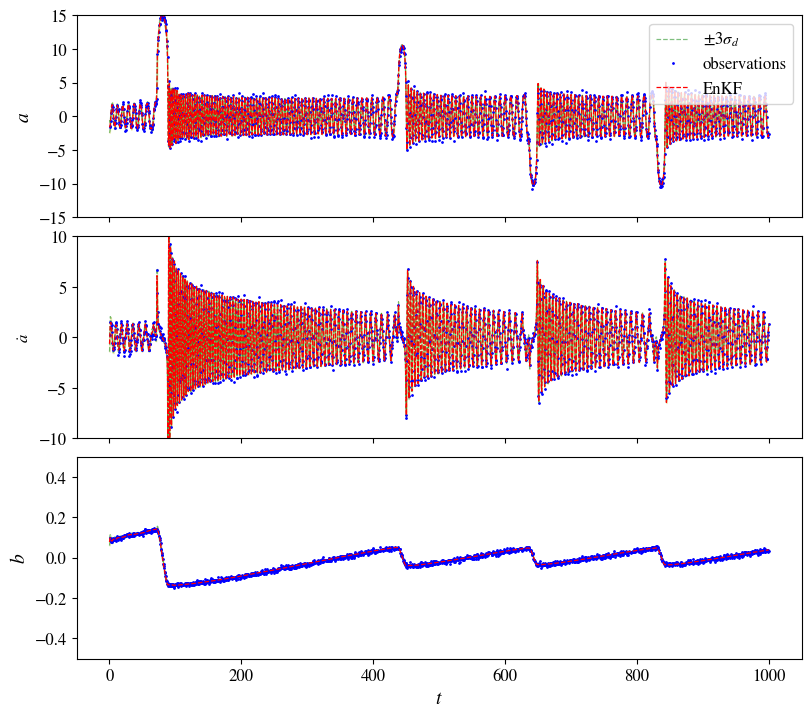

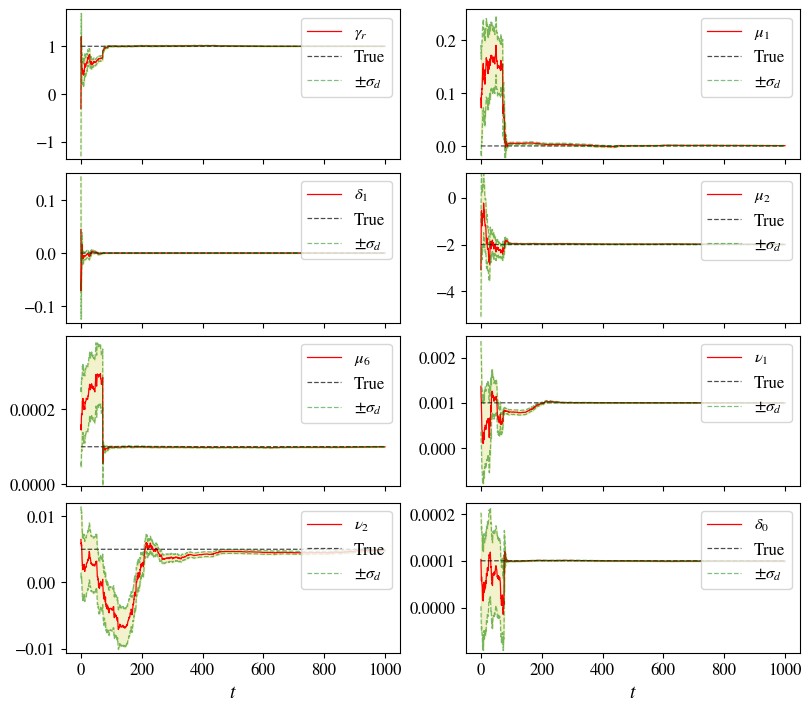

In [ ]:
full_state_plots(observation_times, observation_times, observations, estimates, Pmat, save_fig=False, 
                 save_path="ENKF_figures/ANAET/full_state_measurement/")